<a href="https://colab.research.google.com/github/CelsoM10/API-de-Acoes/blob/main/Projeto_Piloto_Ciencia_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import random

np.random.seed(42)

# ================================================================
# 1. GERAÇÃO DE DADOS FICTÍCIOS DE ATENDIMENTO
# ================================================================

tipos = ["reclamação", "elogio", "dúvida", "cancelamento"]
mensagens_exemplo = {
     "reclamação": ["Produto chegou quebrado", "Não recebi o pedido", "Atendimento ruim"],
     "elogio": ["Gostei muito do produto", "Entrega rápida", "Atendente muito educado"],
     "dúvida": ["Qual o prazo de entrega?", "Como faço para trocar?", "Tem garantia?"],
     "cancelamento": ["Quero cancelar o pedido", "Desejo reembolso", "Cancelar assinatura"] }

dados = []



                  mensagem     categoria
0   Como faço para trocar?        dúvida
1      Cancelar assinatura  cancelamento
2            Tem garantia?        dúvida
3      Não recebi o pedido    reclamação
4  Produto chegou quebrado    reclamação

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

cancelamento       1.00      1.00      1.00        47
      dúvida       1.00      1.00      1.00        60
      elogio       1.00      1.00      1.00        46
  reclamação       1.00      1.00      1.00        47

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Frequência por categoria:
categoria
reclamação      258
dúvida          257
cancelamento    247
elogio          238
Name: count, dtype: int64


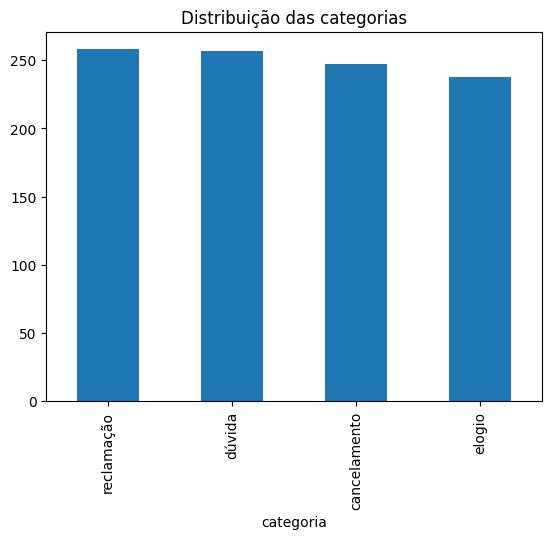

In [ ]:
for i in range(500):
       tipo = random.choice(tipos)
       texto = random.choice(mensagens_exemplo[tipo])
       dados.append([texto, tipo])
df = pd.DataFrame(dados, columns=["mensagem", "categoria"])

print(df.head())


# ================================================================
# 2. NLP — CLASSIFICAÇÃO AUTOMÁTICA
# ================================================================

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["mensagem"])
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, pred))


# ================================================================
# 3. ESTATÍSTICA — ANÁLISE DOS ATENDIMENTOS
# ================================================================


freq = df["categoria"].value_counts()
print("\nFrequência por categoria:")
print(freq)

freq.plot(kind="bar", title="Distribuição das categorias")
plt.show()

# ================================================================
# 4. PESQUISA OPERACIONAL — SIMULAÇÃO DE FILA DE ATENDIMENTO
# ================================================================





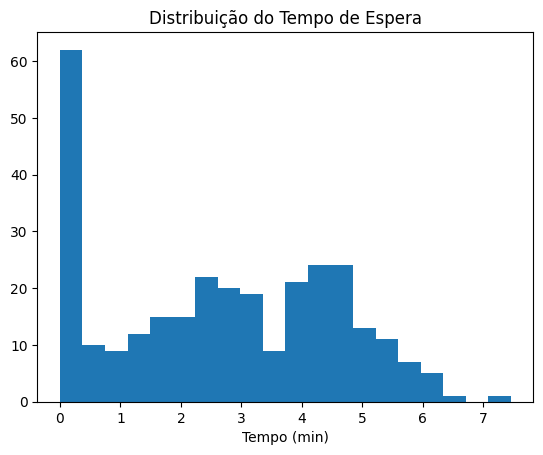


Tempo médio de espera: 2.6397824661209763

Mensagens anonimizadas:
                  mensagem         mensagem_anonima
0   Como faço para trocar?   Como faço para trocar?
1      Cancelar assinatura      Cancelar assinatura
2            Tem garantia?            Tem garantia?
3      Não recebi o pedido      Não recebi o [DADO]
4  Produto chegou quebrado  Produto chegou quebrado


In [ ]:
# Simulação de tempos (em minutos)
tempo_chegada = np.random.exponential(scale=3, size=300)
tempo_atendimento = np.random.normal(loc=5, scale=1, size=300)

tempo_espera = np.maximum(tempo_atendimento - tempo_chegada, 0)

df_fila = pd.DataFrame ({
    "chegada": tempo_chegada,
    "atendimento": tempo_atendimento,
    "espera": tempo_espera })

plt.hist(df_fila["espera"], bins=20)
plt.title("Distribuição do Tempo de Espera")
plt.xlabel("Tempo (min)")
plt.show()
print("\nTempo médio de espera:", df_fila["espera"].mean())



# ================================================================
# 5. SEGURANÇA — ANONIMIZAÇÃO DE TEXTO
# ================================================================




def anonimizar(texto):
   return texto.replace("pedido", "[DADO]").replace("produto", "[DADO]")

df["mensagem_anonima"] = df["mensagem"].apply(anonimizar)

print("\nMensagens anonimizadas:")
print(df[["mensagem", "mensagem_anonima"]].head())

